0. Intialisation And Import

In [45]:

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import os
os.chdir(r'C:\Users\benjo\Documents\Projects\ecg-risk-stratification')
print(os.getcwd())

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
C:\Users\benjo\Documents\Projects\ecg-risk-stratification


In [46]:
binary_df = pd.read_pickle('data/ptbxl_binary_metadata.pkl')
binary_df.head(10)


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,diagnostic_superclass,label
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM],0
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM],0
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM],0
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM],0
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM],0
6,19005.0,18.0,1,NaN,58.0,2.0,0.0,CS-12 E,1984-11-28 13:32:13,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,4,records100/00000/00006_lr,records500/00000/00006_hr,[NORM],0
7,16193.0,54.0,0,NaN,83.0,2.0,0.0,CS-12 E,1984-11-28 13:32:22,"sinusrhythmus linkstyp t abnormal, wahrscheinl...",...,NaN,NaN,NaN,NaN,NaN,7,records100/00000/00007_lr,records500/00000/00007_hr,[NORM],0
9,18792.0,55.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-12-08 09:44:43,sinusrhythmus normales ekg,...,", I-AVR,",NaN,NaN,NaN,NaN,10,records100/00000/00009_lr,records500/00000/00009_hr,[NORM],0
10,9456.0,22.0,1,NaN,56.0,2.0,0.0,CS-12 E,1984-12-12 14:12:46,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,9,records100/00000/00010_lr,records500/00000/00010_hr,[NORM],0


Caching of ECGs to improve loading speed later for training (discovered this was a signigicant time bottleneck when first training)

In [47]:
DATA_DIR = 'data/'
CACHE_DIR = 'data/preprocessed_500'

from src.preprocessing import preprocess_and_cache

preprocess_and_cache(
    df=binary_df,
    data_path=DATA_DIR,
    sampling_rate=500,
    use_filt=True,
    low=0.5,
    high=40,
)

1. Splitting of the Data into training validation and testing folds, this is provided by the dataset itself

In [48]:
train_df = binary_df[binary_df["strat_fold"].isin(range(1, 9))].copy()
val_df = binary_df[binary_df["strat_fold"] == 9].copy()
test_df = binary_df[binary_df["strat_fold"] == 10].copy()
#Testing for Leakage

train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])


print(len(train_patients & val_patients))
print(len(train_patients & test_patients))
print(len(val_patients & test_patients))#Note: in sets the & is the intersection and length shiows how much overlap

0
0
0


In [49]:
print("Train labels:")
print(train_df["label"].value_counts(normalize=True))
print("Val labels:")
print(val_df["label"].value_counts(normalize=True))
print("Test labels:")
print(test_df["label"].value_counts(normalize=True))

Train labels:
label
0    0.633739
1    0.366261
Name: proportion, dtype: float64
Val labels:
label
0    0.633842
1    0.366158
Name: proportion, dtype: float64
Test labels:
label
0    0.636427
1    0.363573
Name: proportion, dtype: float64


2. Pre-Processing

In [50]:
from src.preprocessing import load_and_preprocess
from src.data_extraction import load_ecg

ecg_id = binary_df.index[0]

signal, metadata, row = load_and_preprocess(
    ecg_id,
    binary_df,
    "data/",
    sampling_rate=500
)

print("ECG ID:", ecg_id)
print("Signal shape:", signal.shape)
print("Sampling frequency:", metadata["fs"])
print("Lead names:", metadata["sig_name"])
print("Label:", row["label"])

print("Mean per lead:")
print(signal.mean(axis=1))

print("Std per lead:")
print(signal.std(axis=1))

ECG ID: 1
Signal shape: (12, 5000)
Sampling frequency: 500
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Label: 0
Mean per lead:
[ 1.3732910e-08 -3.0517577e-09  6.1035155e-09  9.9182129e-09
 -2.2888185e-09  8.3923339e-09  3.0517577e-09  5.3405760e-09
  1.5258789e-09 -2.2888185e-09  4.5776369e-09  1.6403199e-08]
Std per lead:
[1.         1.         0.9999997  0.9999999  0.99999976 0.9999997
 0.99999994 0.9999998  0.99999994 0.9999999  0.9999999  0.99999976]


3. Creating the Correct Dataset

In [51]:
from src.dataset import ECGdataset
'''
train_dataset = ECGdataset(
    train_df,
    "data/",
    samp_rate=500,
    use_filt=True,
)

test_dataset = ECGdataset(
    test_df,
    "data/",
    samp_rate=500,
    use_filt=True,
)

val_dataset = ECGdataset(
    val_df,
    "data/",
    samp_rate=500,
    use_filt=True,
)

WITH ADDITION OF CACHING, THIS IS NOW UNNECESSARY AND REPLACED BY BELOW CODE

'''

from src.dataset import CachedECGDataset
train_dataset = CachedECGDataset(train_df, cache_dir=CACHE_DIR)
val_dataset = CachedECGDataset(val_df, cache_dir=CACHE_DIR)
test_dataset = CachedECGDataset(test_df, cache_dir=CACHE_DIR)



4. Dataloader creation 

In [52]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)


5. Model Training 

In [53]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.model import simpleECGNN
from src.training import train_an_epoch, eval

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model = simpleECGNN(dropout=0.3).to(device)


In [54]:
os.makedirs("results/models", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)
os.makedirs("results/metrics", exist_ok=True)

num_pos = train_df["label"].sum()
num_neg = len(train_df) - num_pos
pos_weight = torch.tensor(num_neg / num_pos, dtype=torch.float32).to(device)


criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3,weight_decay=1e-5)

In [55]:
from src.training import train

history = train(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    device,
    num_epochs=30,
    patience=30,
    tolerance=1e-4
)

history_df = pd.DataFrame(history)
history_df.to_csv("results/metrics/training_history.csv", index=False)

Epoch 1/30 - Train Loss: 0.3663 - Val Loss: 0.2932 - Val AUROC: 0.9737 - Val AUPRC: 0.9576 - Val F1: 0.8740
New best model saved with AUROC: 0.9737
Epoch 2/30 - Train Loss: 0.2989 - Val Loss: 0.2793 - Val AUROC: 0.9734 - Val AUPRC: 0.9579 - Val F1: 0.8857
Epoch 3/30 - Train Loss: 0.2886 - Val Loss: 0.2554 - Val AUROC: 0.9757 - Val AUPRC: 0.9609 - Val F1: 0.8964
New best model saved with AUROC: 0.9757
Epoch 4/30 - Train Loss: 0.2809 - Val Loss: 0.2439 - Val AUROC: 0.9778 - Val AUPRC: 0.9643 - Val F1: 0.8983
New best model saved with AUROC: 0.9778
Epoch 5/30 - Train Loss: 0.2747 - Val Loss: 0.2487 - Val AUROC: 0.9768 - Val AUPRC: 0.9635 - Val F1: 0.8977
Epoch 6/30 - Train Loss: 0.2731 - Val Loss: 0.2486 - Val AUROC: 0.9772 - Val AUPRC: 0.9627 - Val F1: 0.8989
Epoch 7/30 - Train Loss: 0.2700 - Val Loss: 0.2441 - Val AUROC: 0.9777 - Val AUPRC: 0.9624 - Val F1: 0.8974
Epoch 8/30 - Train Loss: 0.2688 - Val Loss: 0.2475 - Val AUROC: 0.9777 - Val AUPRC: 0.9629 - Val F1: 0.8946
Epoch 9/30 - Tra

Bottle Neck Finding in Terms of Time

In [56]:
import time

start = time.time()

x, y = next(iter(train_loader))

end = time.time()

print("Time to load one batch:", end - start, "seconds")
print("x shape:", x.shape)
print("y shape:", y.shape)

Time to load one batch: 0.22884464263916016 seconds
x shape: torch.Size([64, 12, 5000])
y shape: torch.Size([64])


In [57]:
num_batches = 20

start = time.time()

for batch_idx, (x, y) in enumerate(train_loader):
    if batch_idx >= num_batches:
        break

end = time.time()

print(f"Loaded {num_batches} batches in {end - start:.2f} seconds")
print(f"Average per batch: {(end - start) / num_batches:.2f} seconds")

Loaded 20 batches in 4.39 seconds
Average per batch: 0.22 seconds


In [58]:
x, y = next(iter(train_loader))

x = x.to(device).float()
y = y.to(device).float()

# Warm-up
for _ in range(5):
    logits = model(x)
    loss = criterion(logits, y)

if device.type == "cuda":
    torch.cuda.synchronize()

start = time.time()

num_runs = 50

for _ in range(num_runs):
    logits = model(x)
    loss = criterion(logits, y)

if device.type == "cuda":
    torch.cuda.synchronize()

end = time.time()

print(f"{num_runs} forward passes took {end - start:.2f} seconds")
print(f"Average forward pass: {(end - start) / num_runs:.4f} seconds")

50 forward passes took 17.20 seconds
Average forward pass: 0.3440 seconds


In [59]:
x, y = next(iter(train_loader))

x = x.to(device).float()
y = y.to(device).float()

logits = model(x)
loss = criterion(logits, y)
loss.backward()
optimizer.step()
optimizer.zero_grad()

if device.type == "cuda":
    torch.cuda.synchronize()

num_runs = 20
start = time.time()

for _ in range(num_runs):
    optimizer.zero_grad()

    logits = model(x)
    loss = criterion(logits, y)

    loss.backward()
    optimizer.step()

if device.type == "cuda":
    torch.cuda.synchronize()

end = time.time()

print(f"{num_runs} full training steps took {end - start:.2f} seconds")
print(f"Average training step: {(end - start) / num_runs:.4f} seconds")

20 full training steps took 20.02 seconds
Average training step: 1.0011 seconds


In [60]:
raw_dataset = ECGdataset(
    train_df,
    "data/",
    samp_rate=500,
    use_filt=True,
)

cached_dataset = CachedECGDataset(
    train_df,
    cache_dir="data/preprocessed_500",
)

idx = 0

start = time.time()
x, y = raw_dataset[idx]
print("Raw single sample:", time.time() - start)

start = time.time()
x, y = cached_dataset[idx]
print("Cached single sample:", time.time() - start)

Raw single sample: 0.0708622932434082
Cached single sample: 0.004458904266357422


In [61]:
workers = [0]
for n in workers:
    raw_loader = DataLoader(
        raw_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=n,
    )

    cached_loader = DataLoader(
        cached_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=n,
    )

    start = time.time()
    for i, (x, y) in enumerate(raw_loader):
        if i >= 20:
            break
    print("Raw 20 batches:", time.time() - start)

    start = time.time()
    for i, (x, y) in enumerate(cached_loader):
        if i >= 20:
            break
    print("Cached 20 batches:", time.time() - start)

Raw 20 batches: 129.01016283035278
Cached 20 batches: 4.779561758041382


In [62]:
batch_sizes = [16, 32, 64, 128]
for n in batch_sizes:
    cached_loader = DataLoader(
        cached_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=0,
    )
    start = time.time()
    for i, (x, y) in enumerate(cached_loader):
        if i >= 20:
            break
    print("Cached 20 batches:", time.time() - start)

Cached 20 batches: 4.460183620452881
Cached 20 batches: 4.385960817337036
Cached 20 batches: 4.3976335525512695
Cached 20 batches: 4.353282690048218


6. Training Curves

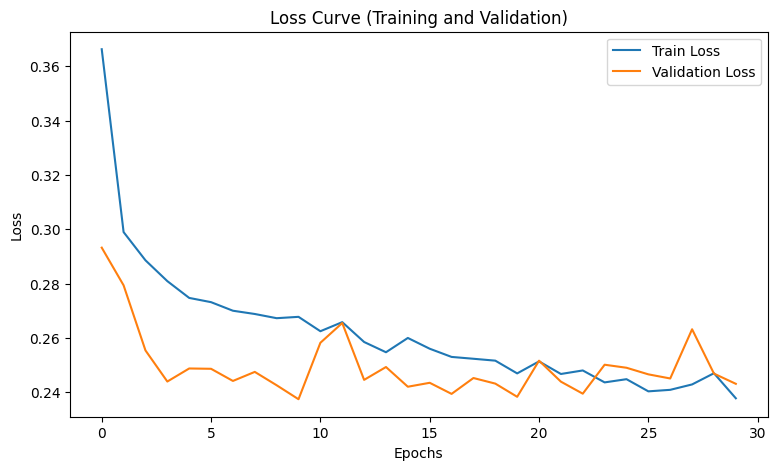

In [63]:
from src.plots import loss_curve, val_metrics

loss_curve(history)

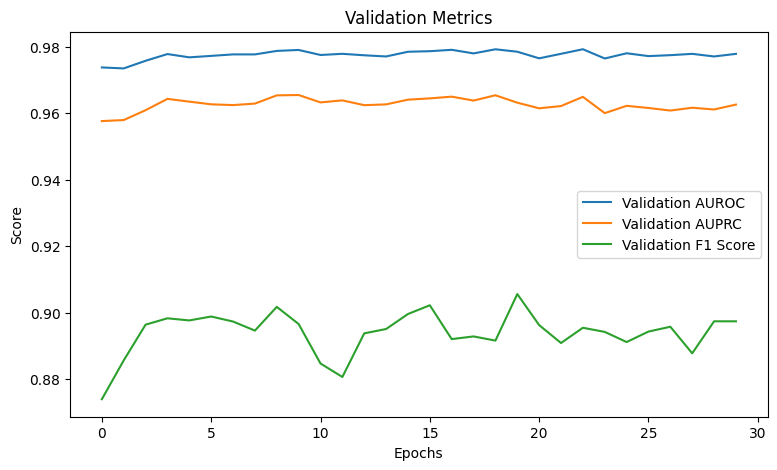

In [64]:
val_metrics(history)

7. Model Evaluation

In [67]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
best_model = simpleECGNN(dropout=0.3).to(device)
best_model.load_state_dict(torch.load("results/models/best_simple_cnn.pt"))

val_metrics, val_labels , val_probs, val_preds = eval(best_model,val_loader,criterion,device)
print("Validation metrics:")
for key, value in val_metrics.items():
    if key != "confusion_matrix":
        print(f"{key}: {value}")

print("Confusion matrix:")
print(val_metrics["confusion_matrix"])



Validation metrics:
loss: 0.24316099910233455
accuracy: 0.9209431345353676
auroc: 0.9791936045355082
auprc: 0.9653736196183429
f1: 0.8916349809885932
Confusion matrix:
[[859  55]
 [ 59 469]]


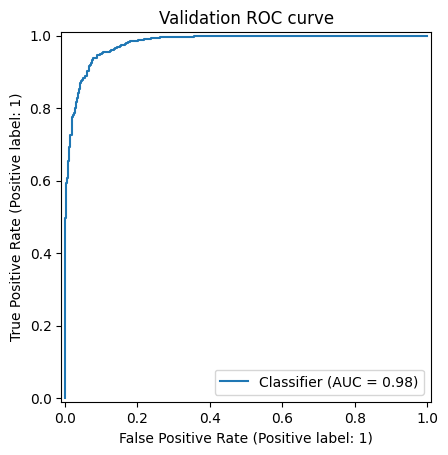

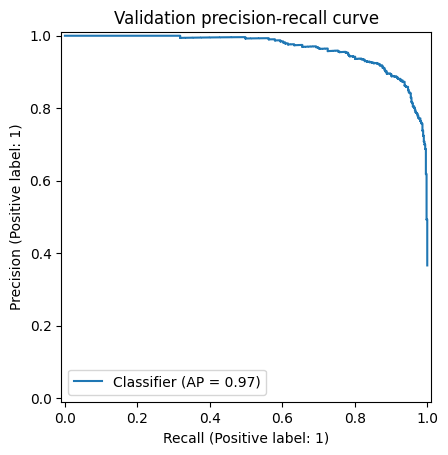

In [66]:
RocCurveDisplay.from_predictions(val_labels, val_probs)
plt.title("Validation ROC curve")
plt.show()

PrecisionRecallDisplay.from_predictions(val_labels, val_probs)
plt.title("Validation precision-recall curve")
plt.show()

Optimal Threshold Finding

In [70]:
from sklearn.metrics import f1_score,precision_recall_curve

f1_scores = []
precision_scores = []
precision, recall, thresholds = precision_recall_curve(val_labels, val_probs)
for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f1_scores.append(f1_score(val_labels, preds))
    
best_index =np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best F1 threshold:", best_threshold)
print("Best F1:", f1_scores[best_index])
print("Precision at best F1:", precision[best_index])
print('Recall at best F1:', recall[best_index])


Best F1 threshold: 0.377286
Best F1: 0.9041095890410958
Precision at best F1: 0.873015873015873
Recall at best F1: 0.9375


Re-evaluation at best f1 threshold

In [73]:
val_metrics, val_labels , val_probs, val_preds = eval(best_model,val_loader,criterion,device,threshold=best_threshold)
print("Validation metrics:")
for key, value in val_metrics.items():
    if key != "confusion_matrix":
        print(f"{key}: {value}")

print("Confusion matrix:")
print(val_metrics["confusion_matrix"])

Validation metrics:
loss: 0.24316099910233455
accuracy: 0.9271844660194175
auroc: 0.9791936045355082
auprc: 0.9653736196183429
f1: 0.9041095890410958
Confusion matrix:
[[842  72]
 [ 33 495]]


Error Analysis

In [75]:
val_results_df = pd.DataFrame()
val_results_df["prob_sttc"] = val_probs
val_results_df["pred_05"] = (val_probs >= 0.5).astype(int)
val_results_df["pred_best_f1"] = val_preds
val_results_df["true_label"] = val_labels.astype(int)

val_results_df.head()

,prob_sttc,pred_05,pred_best_f1,true_label
0,0.004959,0,0,0
1,0.994689,1,1,1
2,0.991920,1,1,1
3,0.666581,1,1,1
4,0.014152,0,0,0


In [ ]:
false_positives = val_results_df[
    (val_results_df["true_label"] == 0) & 
    (val_results_df["pred_best_f1"] == 1)
]

false_negatives = val_results_df[
    (val_results_df["true_label"] == 1) & 
    (val_results_df["pred_best_f1"] == 0)
]
print("False positives:",len(false_positives))
print("False negatives:",len(false_negatives))

False positives: 72
False negatives: 33


In [ ]:
false_positives.sort_values("prob_sttc", ascending=False).head(10)

,prob_sttc,pred_05,pred_best_f1,true_label
468,0.010024,0,0,1
1409,0.034249,0,0,1
387,0.061835,0,0,1
1438,0.067760,0,0,1
617,0.076866,0,0,1
1328,0.087398,0,0,1
192,0.096588,0,0,1
1083,0.108741,0,0,1
715,0.113310,0,0,1
346,0.121647,0,0,1


In [78]:
false_negatives.sort_values("prob_sttc", ascending=True).head(10)

,prob_sttc,pred_05,pred_best_f1,true_label
468,0.010024,0,0,1
1409,0.034249,0,0,1
387,0.061835,0,0,1
1438,0.067760,0,0,1
617,0.076866,0,0,1
1328,0.087398,0,0,1
192,0.096588,0,0,1
1083,0.108741,0,0,1
715,0.113310,0,0,1
346,0.121647,0,0,1
